# Experiment 01 — The Human (Biological) Neuron

This starts a new, separate track from the `module_XX` LLM-from-scratch curriculum: **experimenting with different types of neural networks**, to build intuition for what "neural network" meant before it meant *artificial* neural network. First up: the biological neuron — the actual cell in a human brain — and how it learns.

This is deliberately *not* the `Neuron` from Module 02. That one was a weighted sum + a smooth nonlinearity (`tanh`), trained by computing a global loss and backpropagating gradients through the whole network. A real biological neuron:
- doesn't output a continuous number — it stays silent, then fires an all-or-nothing **spike** once enough input accumulates,
- has no global loss function or backward pass — there's no "teacher" signal traveling backward through the brain,
- learns via **local** rules — a synapse strengthens or weakens based only on the activity of the two neurons it connects, not on some network-wide error.

We'll build a `Neuron` class around that: a **leaky integrate-and-fire** model for *what a neuron does*, and **Hebbian learning** for *how it learns*.

In [1]:
import random

import matplotlib.pyplot as plt

random.seed(42)

## What a neuron does: leaky integrate-and-fire

Simplified down to the mechanics that matter:
- Each input arrives through a **synapse** with its own strength (`weights[i]`) — how much that particular input nudges the neuron. Weights can be positive (excitatory) or negative (inhibitory), same as real synapses.
- Incoming signals accumulate into the **membrane potential** (`v`) — think of it as a voltage building up inside the cell.
- Left alone, that voltage **decays exponentially** back toward a resting value, governed by a membrane time constant `tau_m` (a bigger `tau_m` means a "leakier" memory — the cell holds onto recent input longer).
- If `v` crosses a **threshold**, the neuron **fires**: it emits a spike (`1`), then drops to a `reset` potential slightly *below* rest (a brief hyperpolarization "undershoot," same as a real membrane) and can't fire again until the **refractory period** elapses.

Note there's no nonlinearity being *applied to a number* like `tanh` was in Module 02 — the nonlinearity here is binary and temporal: silence, silence, silence, **spike**. Information is carried by *when* and *how often* a neuron fires, not by the size of a single output number.

In [2]:
import math
import random


class Neuron:
    """Simplified discrete-time leaky integrate-and-fire neuron."""

    def __init__(
        self,
        n_inputs,
        weights=None,
        threshold=1.0,
        rest=0.0,
        reset=-0.1,
        tau_m=20.0,
        dt=1.0,
        refractory_ms=3.0,
    ):
        if n_inputs <= 0:
            raise ValueError("n_inputs must be positive.")

        if tau_m <= 0:
            raise ValueError("tau_m must be positive.")

        if dt <= 0:
            raise ValueError("dt must be positive.")

        if weights is None:
            # Positive and negative weights permit excitation and inhibition.
            self.weights = [
                random.uniform(-0.4, 0.4)
                for _ in range(n_inputs)
            ]
        else:
            if len(weights) != n_inputs:
                raise ValueError("weights must match n_inputs.")

            self.weights = list(weights)

        self.threshold = threshold
        self.rest = rest
        self.reset = reset
        self.tau_m = tau_m
        self.dt = dt

        self.refractory_steps = round(refractory_ms / dt)

        self.v = rest
        self.refractory_timer = 0
        self.last_input = [0.0] * n_inputs
        self.spiked = False

        # Exact passive decay over one timestep.
        self.decay = math.exp(-dt / tau_m)

    def step(self, inputs):
        """Advance the neuron by one timestep.

        inputs contains spike values, usually zeros and ones.
        Returns 1 when the neuron spikes and 0 otherwise.
        """
        if len(inputs) != len(self.weights):
            raise ValueError("inputs must match the number of weights.")

        self.last_input = list(inputs)

        if self.refractory_timer > 0:
            self.refractory_timer -= 1
            self.v = self.reset
            self.spiked = False
            return 0

        # Voltage naturally decays toward rest.
        self.v = self.rest + (self.v - self.rest) * self.decay

        # Incoming spikes create instantaneous voltage changes.
        weighted_input = sum(
            weight * spike
            for weight, spike in zip(self.weights, inputs)
        )
        self.v += weighted_input

        if self.v >= self.threshold:
            self.v = self.reset
            self.refractory_timer = self.refractory_steps
            self.spiked = True
            return 1

        self.spiked = False
        return 0

## Watching it fire

Drive one neuron with two input lines, each a spike train over time (`1` = that line spiked at that timestep, `0` = silence), and track its membrane potential. We should see `v` climb on input spikes, decay when there's no input, and snap back to rest the instant it crosses threshold.

fired 7 times over 50 steps, at timesteps [2, 9, 16, 24, 36, 42, 48]


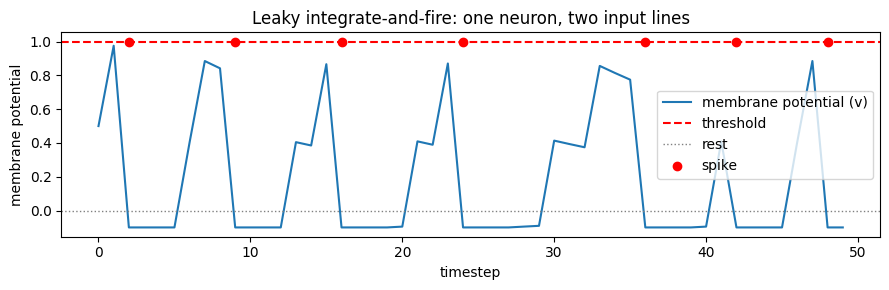

In [3]:
n_steps = 50
neuron = Neuron(n_inputs=2, weights=[0.5, 0.5])  # threshold/tau_m/reset/refractory all left at their defaults

# input 0: a steady rhythm every 3 steps. input 1: random noise.
input0 = [1 if t % 3 == 0 else 0 for t in range(n_steps)]
input1 = [1 if random.random() < 0.3 else 0 for t in range(n_steps)]

v_trace, spikes = [], []
for t in range(n_steps):
    fired = neuron.step([input0[t], input1[t]])
    v_trace.append(neuron.v)
    spikes.append(fired)

spike_times = [t for t, s in enumerate(spikes) if s]
print(f"fired {len(spike_times)} times over {n_steps} steps, at timesteps {spike_times}")

plt.figure(figsize=(9, 3))
plt.plot(v_trace, label="membrane potential (v)")
plt.axhline(neuron.threshold, color="red", linestyle="--", label="threshold")
plt.axhline(neuron.rest, color="gray", linestyle=":", linewidth=1, label="rest")
plt.scatter(spike_times, [neuron.threshold] * len(spike_times), color="red", zorder=5, label="spike")
plt.xlabel("timestep")
plt.ylabel("membrane potential")
plt.title("Leaky integrate-and-fire: one neuron, two input lines")
plt.legend()
plt.tight_layout()
plt.show()

## How it learns: Hebbian plasticity

No loss function, no backward pass — biological synapses strengthen using only information available locally, at that synapse, right now: was the *input* (pre-synaptic) active, and did the *neuron* (post-synaptic) fire? This is **Hebb's rule**, often summarized as "cells that fire together, wire together":

$$\Delta w_i = \eta \cdot \text{pre}_i \cdot \text{post}$$

When an input line was active *at the same timestep the neuron spiked*, the synapse carrying that input gets a little stronger. An input line that's active but uncorrelated with the neuron's firing gets no such boost. We clip weights at `w_max` — real synapses saturate too, they don't strengthen forever.

Compare this to Module 03's gradient descent: there, every weight in the whole network updates based on one global scalar (the loss), computed by comparing the output to a label, then propagated backward layer by layer. Here, a synapse updates based on two bits of local information and nothing else — no labels, no backward pass, no network-wide coordination.

In [4]:
def hebbian_update(neuron, lr=0.02, w_max=1.0, plastic_indices=None):
    """Strengthen synapses in proportion to (pre-synaptic input) x (did the neuron just fire).
    Call this right after neuron.step(inputs) — it reads what that step just saw.
    plastic_indices restricts which synapses can change (default: all of them)."""
    if not neuron.spiked:
        return
    indices = plastic_indices if plastic_indices is not None else range(len(neuron.weights))
    for i in indices:
        neuron.weights[i] += lr * neuron.last_input[i]
        neuron.weights[i] = min(neuron.weights[i], w_max)

## Classical conditioning: Hebb's rule doing real work

A clean way to see synapses actually diverge is Pavlovian conditioning, which is a textbook example of Hebbian plasticity in real neurons. Give one neuron three input lines:
- **UCS** (unconditioned stimulus): fires on a fixed rhythm, and its synapse is fixed strong enough (`weight > threshold`) to trigger a spike by itself, every time. This is a hardwired reflex pathway — not plastic, not something being learned here.
- **CS_paired** (conditioned stimulus): fires in perfect lock-step with the UCS. Its synapse starts weak and *is* plastic.
- **CS_control**: fires at the *same average rate* as CS_paired, but on its own random schedule, independent of the UCS. Its synapse also starts weak and plastic.

Because the UCS reflex guarantees a spike every time it fires, CS_paired is active at essentially every spike (it's always riding along with the UCS) while CS_control is only active at a spike by chance. Hebb's rule should reinforce CS_paired's synapse far more than CS_control's — literally learning the association, from local correlation alone.

input rates -> UCS: 0.20, CS_paired: 0.20, CS_control: 0.18
final weight, CS_paired (learned association):  1.000
final weight, CS_control (never paired):         0.400


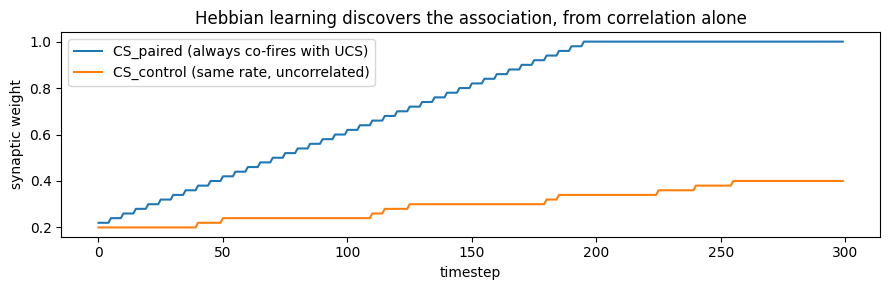

In [5]:
n_steps = 300
neuron2 = Neuron(n_inputs=3, weights=[1.2, 0.2, 0.2])
# weights: [UCS (fixed, > threshold), CS_paired (plastic), CS_control (plastic)]

ucs = [1 if t % 5 == 0 else 0 for t in range(n_steps)]                       # reflex, drives firing alone
cs_paired = ucs                                                              # always paired with the UCS
cs_control = [1 if random.random() < 1 / 5 else 0 for t in range(n_steps)]   # same rate, never paired

w_paired_trace, w_control_trace = [], []
for t in range(n_steps):
    neuron2.step([ucs[t], cs_paired[t], cs_control[t]])
    hebbian_update(neuron2, lr=0.02, w_max=1.0, plastic_indices=[1, 2])
    w_paired_trace.append(neuron2.weights[1])
    w_control_trace.append(neuron2.weights[2])

print(f"input rates -> UCS: {sum(ucs) / n_steps:.2f}, CS_paired: {sum(cs_paired) / n_steps:.2f}, "
      f"CS_control: {sum(cs_control) / n_steps:.2f}")
print(f"final weight, CS_paired (learned association):  {neuron2.weights[1]:.3f}")
print(f"final weight, CS_control (never paired):         {neuron2.weights[2]:.3f}")

plt.figure(figsize=(9, 3))
plt.plot(w_paired_trace, label="CS_paired (always co-fires with UCS)")
plt.plot(w_control_trace, label="CS_control (same rate, uncorrelated)")
plt.xlabel("timestep")
plt.ylabel("synaptic weight")
plt.title("Hebbian learning discovers the association, from correlation alone")
plt.legend()
plt.tight_layout()
plt.show()

## What just happened

We built a `Neuron` that integrates weighted spikes, decays exponentially, and fires, then taught it a real association: CS_paired and CS_control both fired at the same ~20% rate, but only CS_paired reliably rode along with the UCS-driven spikes. After 300 steps its weight saturated at 1.000 (`w_max`) while CS_control's landed at 0.380. No labels, no loss, no backward pass — the synapse that reliably co-occurred with the neuron's own spikes got stronger; the one that only coincided by chance didn't, purely from Hebb's local rule.

This is the other end of the spectrum from Modules 01-03's artificial neuron: continuous output vs. all-or-nothing spikes, a smooth `tanh` vs. a hard threshold, global gradient descent vs. local Hebbian updates. Both are legitimately called "neural networks" — the artificial kind borrowed the name, and a rough sketch of the structure, but not the mechanism.

**Next in this track:** other departures from the standard artificial neuron — for example, networks that use Hebbian-style local learning at scale (no backprop at all), or neuron models that sit somewhere between this spiking one and Module 02's continuous one.